# Dimensionality reduction

Apply several dimensionalality reduction methods for RotADeL data 2D visualisation:
- UMAP
- FloDR

Steps:
1. Create a balanced subset of 250'000 rotamers, distributed as equally between amino acids as availability permits
2. Standardise the subset
3. Fit dim red method on the subset
4. Plot coloured by AA

In [1]:
from __future__ import annotations

import heapq
import importlib.abc
import json
import sqlite3
import sys
import warnings
from pathlib import Path

import distinctipy
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, LogNorm, to_rgb
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
import numpy as np
import pandas as pd
from IPython.display import display
from scipy.sparse.csgraph import connected_components
from sklearn.preprocessing import StandardScaler
from seaborn.external.husl import husl_to_rgb, rgb_to_husl


# umap-learn eagerly imports optional TensorFlow-based ParametricUMAP support.
# Block only that unused module to avoid TensorFlow/CUDA/protobuf import noise.
class _BlockParametricUMAP(importlib.abc.MetaPathFinder):
    def find_spec(self, fullname, path=None, target=None):
        if fullname == "umap.parametric_umap":
            raise ImportError("ParametricUMAP is not used in this notebook")


_blocker = _BlockParametricUMAP()
sys.meta_path.insert(0, _blocker)
try:
    with warnings.catch_warnings():
        warnings.filterwarnings("ignore", message="IProgress not found.*")
        warnings.filterwarnings("ignore", category=ImportWarning)
        from umap import UMAP
finally:
    sys.meta_path.remove(_blocker)

from rotadel.common.config import SQL_PATH
from rotadel.common.constants import (
    NUMBER_OF_CHI_ANGLES,
    ONE_TO_THREE_AA,
    THREE_TO_ONE_AA,
)

In [2]:
RANDOM_SEED = 42

SQL_PATH = Path(SQL_PATH).resolve()
if not SQL_PATH.is_file():
    raise FileNotFoundError(f"Rotadel database not found: {SQL_PATH}")
print(f"RotADeL sql path: {SQL_PATH}")

FIG_PATH = Path("figures").resolve()
print(f"Path to save plots: {FIG_PATH}")

RotADeL sql path: /cluster/project/jorner/lajacot/projects/rotadel/database/rotadel.db
Path to save plots: /cluster/project/jorner/lajacot/projects/rotadel/visualisation/distributions/figures


## Calculate sampling quotas

Dimensionality reduction applied on subset of RotADeL according the following:

- Included descriptors: only molecular descriptors (atomic ones are too AA specific) and exclude total charge (doesn't variate accross rotamers)
- Balanced subset: sample a total of 250'000 rotamers; all rows from small ensembles, then equal allocation across remaining amino acids

In [3]:
BALANCED_DISPLAY_SIZE = 250_000


def connect_read_only(path: Path = SQL_PATH) -> sqlite3.Connection:
    return sqlite3.connect(f"file:{path}?mode=ro", uri=True)


def database_summary(path: Path = SQL_PATH) -> tuple[pd.Series, list[str]]:
    """Return residue counts and the continuous molecular descriptor names."""
    with connect_read_only(path) as connection:
        rows = connection.execute(
            "SELECT res, COUNT(*) FROM rotamers_data GROUP BY res ORDER BY res"
        ).fetchall()
        descriptor_json = connection.execute(
            "SELECT descriptors FROM rotamers_data WHERE descriptors IS NOT NULL LIMIT 1"
        ).fetchone()

    if not rows or descriptor_json is None:
        raise ValueError("The database contains no usable rotamer descriptors.")

    counts = pd.Series(dict(rows), name="library_count", dtype="int64")
    example = json.loads(descriptor_json[0])
    names = [
        name
        for name, value in example.items()
        if name != "charge_tot"
        and isinstance(value, (int, float))
        and not isinstance(value, bool)
    ]
    if len(names) != 18:
        raise ValueError(f"Expected 18 continuous descriptors; found {names}")
    return counts, names


def balanced_display_quotas(
    counts: pd.Series, target: int = BALANCED_DISPLAY_SIZE
) -> pd.Series:
    """Distribute the display sample as evenly as residue capacities allow."""
    target = min(target, int(counts.sum()))
    if target < len(counts):
        raise ValueError("Sample target must allow at least one row per residue.")

    quotas = pd.Series(0, index=counts.index, dtype="int64")
    remaining = target
    while remaining:
        active = counts > quotas
        share = remaining // int(active.sum())
        if share == 0:
            quotas.loc[quotas.index[active][:remaining]] += 1
            break
        additions = np.minimum(share, (counts - quotas)[active])
        quotas.loc[active] += additions
        remaining -= int(additions.sum())

    if int(quotas.sum()) != target:
        raise RuntimeError("Could not construct valid balanced display quotas.")
    return quotas

In [4]:
# Calculate balanced display quotas
library_counts, descriptor_names = database_summary()
if set(library_counts.index) != set(ONE_TO_THREE_AA.values()):
    raise ValueError("Database residues do not match ONE_TO_THREE_AA.")

balanced_display_quotas_by_residue = balanced_display_quotas(library_counts)

In [5]:
# Display sampling statistics
sampling_audit = pd.DataFrame(
    {
        "library_count": library_counts,
        "balanced_display_count": balanced_display_quotas_by_residue,
    }
)

print(f"Library: {int(library_counts.sum())} rotamers")
print(f"Descriptors ({len(descriptor_names)}): {descriptor_names}")
print(f"Balanced display subset: {int(balanced_display_quotas_by_residue.sum())}")
display(sampling_audit)

Library: 973247 rotamers
Descriptors (18): ['v_bur', 'sasa_tot', 'sasa_polar', 'sasa_unpolar', 'sterimol_l', 'sterimol_b1', 'sterimol_b5', 'cone_angle', 'p_int', 'homo', 'lumo', 'electron_affinity', 'ionization_potential', 'electronegativity', 'hardness', 'dipole', 'global_nucleophilicity', 'global_electrophilicity']
Balanced display subset: 250000


,library_count,balanced_display_count
ALA,1,1
ARG,97200,18604
ASN,46642,18604
ASP,46652,18604
CYS,7776,7776
GLN,139968,18604
GLU,139964,18604
GLY,1,1
HIS,139968,18603
ILE,11664,11664


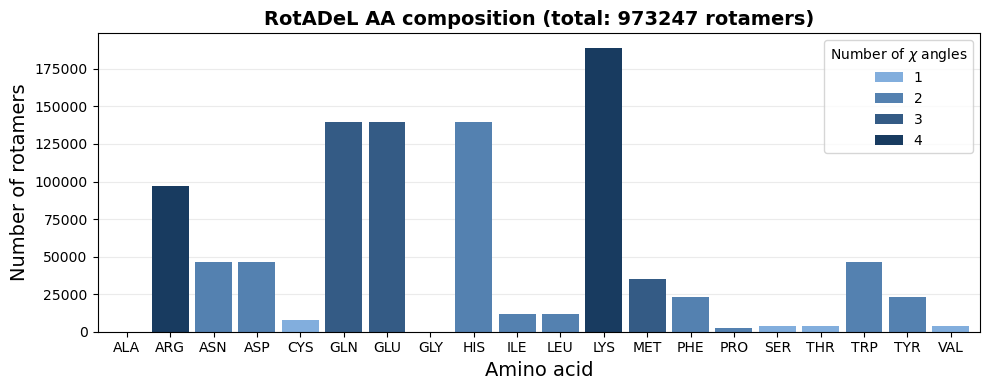

In [6]:
# Plot AA composition, coloured by side-chain flexibility
chi_colors = {
    0: "#96a2af",
    1: "#82aedd",
    2: "#5481b0",
    3: "#345b85",
    4: "#183b60",
}
bar_colors = [
    chi_colors[NUMBER_OF_CHI_ANGLES[THREE_TO_ONE_AA[residue]]]
    for residue in library_counts.index
]

fig, ax = plt.subplots(figsize=(10, 4))
library_counts.plot.bar(ax=ax, color=bar_colors, width=0.85)
ax.set_title(
    f"RotADeL AA composition (total: {int(library_counts.sum())} rotamers)",
    fontsize=14,
    fontweight="bold",
)
ax.set_xlabel("Amino acid", fontsize=14)
ax.set_ylabel("Number of rotamers", fontsize=14)
ax.tick_params(axis="x", labelrotation=0)
ax.set_axisbelow(True)
ax.grid(axis="y", alpha=0.25)
ax.legend(
    handles=[
        Patch(facecolor=chi_colors[n_chi], label=str(n_chi)) for n_chi in range(1, 5)
    ],
    title=r"Number of $\chi$ angles",
    loc="upper right",
    frameon=True,
)
fig.tight_layout()

# Uncomment to save figure
# fig.savefig(FIG_PATH / "aa_composition.png", dpi=600, bbox_inches="tight")

## Extract balanced subset

In [7]:
FETCH_SIZE = 10_000


def stream_reservoirs(
    names: list[str],
    quotas: pd.Series,
    path: Path = SQL_PATH,
    seed: int = RANDOM_SEED,
) -> dict[str, list]:
    """Stream the database into reproducible bounded per-residue reservoirs."""
    rng = np.random.default_rng(seed)
    heaps = {residue: [] for residue in quotas.index}
    processed = 0

    with connect_read_only(path) as connection:
        cursor = connection.execute(
            "SELECT rotamer_id, res, prob, descriptors FROM rotamers_data "
            "WHERE descriptors IS NOT NULL ORDER BY rowid"
        )
        while rows := cursor.fetchmany(FETCH_SIZE):
            for rotamer_id, residue, prob, descriptor_json in rows:
                descriptors = json.loads(descriptor_json)
                values = tuple(float(descriptors[name]) for name in names)
                if (
                    not np.isfinite(values).all()
                    or prob is None
                    or not np.isfinite(prob)
                ):
                    raise ValueError(f"Invalid data in {rotamer_id!r}")

                priority = float(rng.random())
                entry = (
                    -priority,
                    rotamer_id,
                    (rotamer_id, residue, float(prob), *values),
                )
                heap = heaps[residue]
                quota = int(quotas[residue])
                if len(heap) < quota:
                    heapq.heappush(heap, entry)
                elif entry > heap[0]:
                    heapq.heapreplace(heap, entry)

            processed += len(rows)
            if processed % 200_000 < FETCH_SIZE:
                print(f"Processed {processed} rotamers")
    return heaps


def sample_frame(heaps: dict, quotas: pd.Series, names: list[str]) -> pd.DataFrame:
    """Extract a sample from the per-residue reservoirs."""
    records = [
        entry[2]
        for residue, quota in quotas.items()
        for entry in sorted(heaps[residue], reverse=True)[: int(quota)]
    ]
    frame = pd.DataFrame(records, columns=["rotamer_id", "res", "prob", *names])
    if len(frame) != int(quotas.sum()):
        raise RuntimeError("Sample size does not match its quotas.")
    return frame

In [8]:
# Sample balanced display subset
reservoirs = stream_reservoirs(
    descriptor_names,
    balanced_display_quotas_by_residue,
)
balanced_display = sample_frame(
    reservoirs,
    balanced_display_quotas_by_residue,
    descriptor_names,
)

print(f"Balanced display subset loaded: {len(balanced_display)}")

Processed 200000 rotamers
Processed 400000 rotamers
Processed 600000 rotamers
Processed 800000 rotamers
Balanced display subset loaded: 250000


## Plot configuration

Possible colouring schemes:
- Only by amino acid, with each point coloured according to its amino acid
- By amino acid and rotamer probability - one colour hue for each amino acid, and then lightness corresponding to the conditional side-chain probability of this rotamer
- The rotamers of only one selected AA (whether by probability or not)

In [9]:
# --- For colouring scheme with only amino acid

POINT_SIZE = 3
POINT_ALPHA = 0.6

# Categorise AA by biochemical properties for grouped colouring/legend
AA_GROUPS = {
    "Positive": ["LYS", "ARG", "HIS"],
    "Negative": ["ASP", "GLU"],
    "Polar uncharged": ["CYS", "SER", "THR", "ASN", "GLN"],
    "Nonpolar aliphatic": ["GLY", "ALA", "VAL", "ILE", "LEU", "MET", "PRO"],
    "Nonpolar aromatic": ["PHE", "TYR", "TRP"],
}
grouped_residue_order = [
    residue for group_residues in AA_GROUPS.values() for residue in group_residues
]
if "library_counts" in globals():
    available_residues = set(library_counts.index)
else:
    available_residues = set(balanced_display["res"].unique())
unexpected_residues = available_residues.difference(grouped_residue_order)
if unexpected_residues:
    raise ValueError(f"Amino acids missing from AA_GROUPS: {unexpected_residues}")
residue_order = [
    residue for residue in grouped_residue_order if residue in available_residues
]

# Create a map of distinct colors for each amino acid, sorted by hue for visual
distinct_colors = sorted(
    distinctipy.get_colors(len(residue_order), rng=RANDOM_SEED),
    key=lambda color: rgb_to_husl(*color)[0],
)
residue_colors = dict(zip(residue_order, distinct_colors, strict=True))
# Change a few colours which were hard to distinguish
residue_colors.update(
    {
        "CYS": to_rgb("gold"),
        "GLN": to_rgb("green"),
        "GLY": to_rgb("aquamarine"),
    }
)


def make_grouped_legend_handles(
    residues: list[str],
    colors: dict[str, tuple[float, ...] | list[float]],
) -> list[Patch | Line2D]:
    """Build a one-column amino-acid legend with AA biochemical category headings."""
    included_residues = set(residues)
    handles = []
    for group_name, group_residues in AA_GROUPS.items():
        visible_residues = [
            residue for residue in group_residues if residue in included_residues
        ]
        if not visible_residues:
            continue
        handles.append(Patch(facecolor="none", edgecolor="none", label=group_name))
        handles.extend(
            Line2D(
                [0],
                [0],
                marker="o",
                linestyle="none",
                markerfacecolor=colors[residue],
                markeredgecolor="none",
                markersize=8,
                alpha=1.0,
                label=residue,
            )
            for residue in visible_residues
        )
    return handles


legend_handles = make_grouped_legend_handles(residue_order, residue_colors)

# --- For colouring scheme with side-chain probability

# Lightness Probability scale: logarithmic
# + clipped to 1e-4 to 1; zero and smaller values use the palest level
PROBABILITY_FLOOR = 1e-4
PROBABILITY_LEVELS = 256  # lightness levels: efficient for 250'000 points
PROBABILITY_SATURATION = 85
PROBABILITY_LIGHTNESS_LOW = 90  # low probability: pale
PROBABILITY_LIGHTNESS_HIGH = 35  # high probability: dark
REFERENCE_LIGHTNESS = 55

HIGHLIGHT_COLOR = "sandybrown"
HIGHLIGHT_RGB = np.asarray(to_rgb(HIGHLIGHT_COLOR))
HIGHLIGHT_HUE, HIGHLIGHT_SATURATION, _ = rgb_to_husl(*HIGHLIGHT_RGB)

# Hue for amino acid: 18 evenly spaced HUSL hues at equal reference lightness
# + ALA/GLY omitted because each has only one geometry
# + no transparency because would interfere with lightness encoding
probability_residues = [
    residue for residue in residue_order if residue not in {"ALA", "GLY"}
]
hue_by_residue = {
    residue: 360 * index / len(probability_residues)
    for index, residue in enumerate(probability_residues)
}
lightness_levels = np.linspace(
    PROBABILITY_LIGHTNESS_LOW,
    PROBABILITY_LIGHTNESS_HIGH,
    PROBABILITY_LEVELS,
)
color_lookup = {
    residue: np.asarray(
        [
            husl_to_rgb(
                hue_by_residue.get(residue, 0),
                PROBABILITY_SATURATION if residue in hue_by_residue else 0,
                lightness,
            )
            for lightness in lightness_levels
        ]
    )
    for residue in residue_order
}
probability_cmap = ListedColormap(
    [husl_to_rgb(0, 0, lightness) for lightness in lightness_levels]
)
highlight_probability_colors = np.asarray(
    [
        husl_to_rgb(HIGHLIGHT_HUE, HIGHLIGHT_SATURATION, lightness)
        for lightness in lightness_levels
    ]
)
highlight_probability_cmap = ListedColormap(highlight_probability_colors)
probability_reference_colors = {
    residue: husl_to_rgb(
        hue_by_residue[residue],
        PROBABILITY_SATURATION,
        REFERENCE_LIGHTNESS,
    )
    for residue in probability_residues
}
probability_legend_handles = make_grouped_legend_handles(
    probability_residues, probability_reference_colors
)


# --- For plotting embeddings


def plot_embedding(
    frame: pd.DataFrame,
    coordinate_columns: tuple[str, str] | list[str],
    title: str | None = None,
    colour_by_prob: bool = False,
    highlight_residue: str | None = None,
    save_path: Path | str | None = None,
) -> None:
    """Plot an embedding, optionally highlighting one amino acid against grey points."""
    if len(coordinate_columns) != 2:
        raise ValueError("Exactly two coordinate columns are required.")
    x_column, y_column = coordinate_columns
    plot_frame = frame.sample(frac=1, random_state=RANDOM_SEED)

    if highlight_residue is not None:
        highlight_residue = highlight_residue.upper()
        if highlight_residue not in residue_colors:
            raise ValueError(
                f"Unknown amino acid {highlight_residue!r}; choose from {residue_order}."
            )
        is_highlighted = plot_frame["res"] == highlight_residue
        plot_frame = pd.concat(
            [plot_frame.loc[~is_highlighted], plot_frame.loc[is_highlighted]]
        )

    if colour_by_prob:
        probabilities = np.clip(
            plot_frame["prob"].to_numpy(dtype=float),
            PROBABILITY_FLOOR,
            1.0,
        )
        probability_strength = (
            np.log10(probabilities) - np.log10(PROBABILITY_FLOOR)
        ) / -np.log10(PROBABILITY_FLOOR)
        level_indices = np.rint(probability_strength * (PROBABILITY_LEVELS - 1)).astype(
            int
        )

        point_colors = np.empty((len(plot_frame), 3))
        residues = plot_frame["res"].to_numpy()
        for residue in residue_order:
            mask = residues == residue
            point_colors[mask] = color_lookup[residue][level_indices[mask]]

        if highlight_residue is None:
            fig = plt.figure(figsize=(12, 8), layout="constrained")
            grid = fig.add_gridspec(
                1, 4, width_ratios=(1, 0.03, 0.035, 0.20), wspace=0.02
            )
            ax = fig.add_subplot(grid[0, 0])
            colorbar_ax = fig.add_subplot(grid[0, 2])
            legend_ax = fig.add_subplot(grid[0, 3])
            legend_ax.axis("off")
        else:
            fig = plt.figure(figsize=(10, 8), layout="constrained")
            grid = fig.add_gridspec(1, 3, width_ratios=(1, 0.03, 0.035), wspace=0.02)
            ax = fig.add_subplot(grid[0, 0])
            colorbar_ax = fig.add_subplot(grid[0, 2])
            legend_ax = ax
        ax.set_anchor("E")
        point_alpha = 1.0
    else:
        plot_residues = plot_frame["res"].to_numpy(dtype=object)
        point_colors = np.asarray(
            [residue_colors[residue] for residue in plot_residues]
        )
        fig, ax = plt.subplots(figsize=(10, 8), layout="constrained")
        legend_ax = ax
        point_alpha = POINT_ALPHA

    if highlight_residue is not None:
        highlight_mask = plot_frame["res"].to_numpy() == highlight_residue
        grey = np.full(point_colors.shape[1], 0.75)
        if point_colors.shape[1] == 4:
            grey[-1] = 1.0
            point_colors[highlight_mask] = np.append(HIGHLIGHT_RGB, 1.0)
        else:
            point_colors[highlight_mask] = highlight_probability_colors[
                level_indices[highlight_mask]
            ]
        point_colors[~highlight_mask] = grey
        highlight_handles = [
            Line2D(
                [0],
                [0],
                marker="o",
                linestyle="none",
                markerfacecolor=HIGHLIGHT_COLOR,
                markeredgecolor="none",
                markersize=8,
                label=f"{highlight_residue} rotamers",
            ),
            Line2D(
                [0],
                [0],
                marker="o",
                linestyle="none",
                markerfacecolor=grey,
                markeredgecolor="none",
                markersize=8,
                label="Other amino acids",
            ),
        ]

    ax.scatter(
        plot_frame[x_column],
        plot_frame[y_column],
        s=POINT_SIZE,
        alpha=point_alpha,
        color=point_colors,
        edgecolors="none",
        rasterized=True,
    )
    if title is not None:
        ax.set_title(title, fontsize=15, fontweight="bold")
    ax.set_box_aspect(1)
    ax.set_xticks([])
    ax.set_yticks([])

    if highlight_residue is not None:
        legend_ax.legend(
            handles=highlight_handles,
            loc="upper right",
            frameon=False,
            fontsize=12 if colour_by_prob else 13,
        )
    elif colour_by_prob:
        legend = legend_ax.legend(
            handles=probability_legend_handles,
            title="Amino acid",
            loc="center left",
            frameon=False,
            ncols=1,
            fontsize=12,
            title_fontsize=13,
        )
    else:
        legend = legend_ax.legend(
            handles=legend_handles,
            title="Amino acid",
            loc="center left",
            bbox_to_anchor=(1.01, 0.5),
            frameon=False,
            ncols=1,
            fontsize=13,
            title_fontsize=14,
        )

    if highlight_residue is None:
        for legend_text in legend.get_texts():
            if legend_text.get_text() in AA_GROUPS:
                legend_text.set_fontweight("bold")

    if colour_by_prob:
        colorbar_cmap = (
            highlight_probability_cmap
            if highlight_residue is not None
            else probability_cmap
        )
        probability_mappable = plt.cm.ScalarMappable(
            norm=LogNorm(vmin=PROBABILITY_FLOOR, vmax=1.0),
            cmap=colorbar_cmap,
        )
        colorbar = fig.colorbar(
            probability_mappable,
            cax=colorbar_ax,
            extend="min",
        )
        colorbar.set_label("Conditional side-chain probability", fontsize=14)

    if save_path is not None:
        fig.savefig(save_path, dpi=600, bbox_inches="tight")

    plt.show()

## UMAP

In [10]:
# Runtime: ~4 min

UMAP_COORDINATE_COLUMNS = ["umap_1", "umap_2"]

umap_display = balanced_display.copy()
umap_scaler = StandardScaler()
umap_balanced_scaled = umap_scaler.fit_transform(umap_display[descriptor_names])
# PCA provides a deterministic non-random initialization and avoids the
# spectral solver failures encountered with the previous UMAP runs.
umap_model = UMAP(
    n_components=2,
    n_neighbors=15,
    min_dist=0.1,
    metric="euclidean",
    init="pca",
    random_state=RANDOM_SEED,
    n_jobs=1,
    transform_seed=RANDOM_SEED,
    low_memory=True,
)
umap_display[UMAP_COORDINATE_COLUMNS] = umap_model.fit_transform(umap_balanced_scaled)

umap_graph_component_count, umap_graph_component_labels = connected_components(
    umap_model.graph_, directed=False
)
umap_graph_component_sizes = np.bincount(umap_graph_component_labels)
print(
    f"UMAP graph: {umap_graph_component_count} connected components; "
    f"largest contains {umap_graph_component_sizes.max()} points; "
    f"{np.count_nonzero(umap_graph_component_sizes == 1)} singletons"
)

finite = np.isfinite(umap_display[UMAP_COORDINATE_COLUMNS]).all(axis=1)
if omitted := int((~finite).sum()):
    print(f"Omitted {omitted} disconnected points.")
umap_display = umap_display.loc[finite].copy()

UMAP graph: 1467 connected components; largest contains 7307 points; 0 singletons


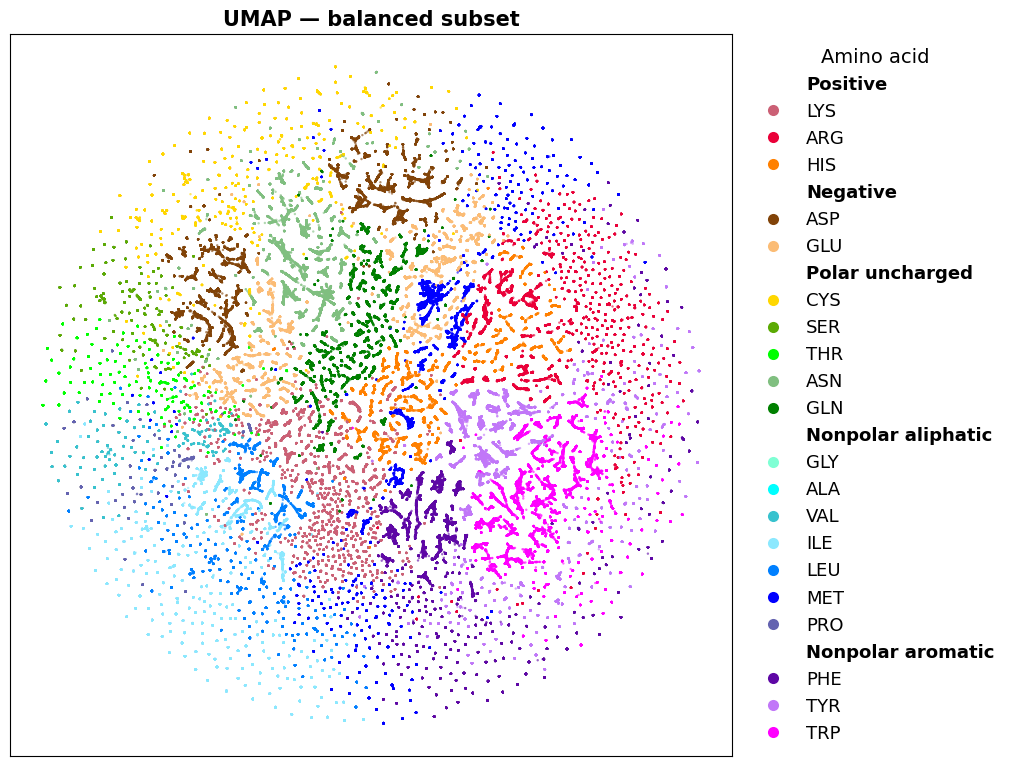

In [20]:
plot_embedding(
    umap_display,
    UMAP_COORDINATE_COLUMNS,
    "UMAP — balanced subset",
    save_path=FIG_PATH / "umap_balanced.png",
)

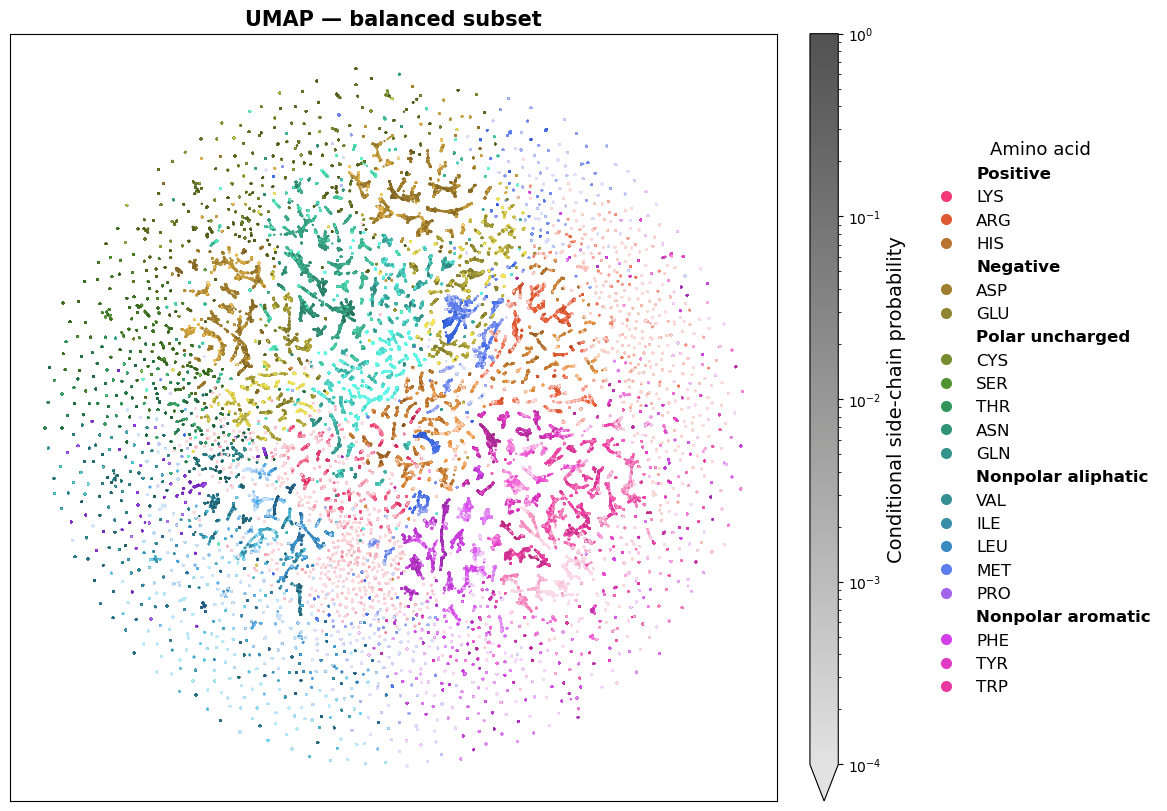

In [21]:
plot_embedding(
    umap_display,
    UMAP_COORDINATE_COLUMNS,
    "UMAP — balanced subset",
    colour_by_prob=True,
)

## FloDR

Two-dimensional view of the 18 continuous molecular descriptors, colored by amino acid.

1. Standardise the balanced display descriptors.
2. Fit FloDR directly on the balanced display subset — all displayed points determine the map.
3. Plot the embedding with the same colouring schemes as UMAP.

FloDR performs dimensionality reduction only; no clustering algorithm is applied.

In [13]:
import flodr
import torch

print(f"GPU available: {torch.cuda.is_available()}")

GPU available: True


In [14]:
# Runtime: ~2 min

FLODR_BALANCED_COORDINATE_COLUMNS = ["flodr_1", "flodr_2"]

flodr_balanced_display = balanced_display.copy()
flodr_balanced_scaler = StandardScaler()
flodr_balanced_scaled = flodr_balanced_scaler.fit_transform(
    flodr_balanced_display[descriptor_names]
).astype(np.float32)
flodr_balanced_model = flodr.FloDR(
    w=2.0,
    random_state=RANDOM_SEED,
    density=False,
    n_components=2,
)
print(f"FloDR device: {flodr_balanced_model.device}")

flodr_balanced_display[FLODR_BALANCED_COORDINATE_COLUMNS] = (
    flodr_balanced_model.fit_transform(
        flodr_balanced_scaled,
        iters=800,
    )
)

print(f"FloDR embedding: {flodr_balanced_model.embedding_.shape}")
print(f"FloDR round-trip max absolute error: {flodr_balanced_model.roundtrip_:.2e}")

finite = np.isfinite(flodr_balanced_display[FLODR_BALANCED_COORDINATE_COLUMNS]).all(
    axis=1
)
if omitted := int((~finite).sum()):
    print(f"Omitted {omitted} non-finite FloDR points.")
flodr_balanced_display = flodr_balanced_display.loc[finite].copy()

FloDR device: cuda
FloDR embedding: (250000, 2)
FloDR round-trip max absolute error: 2.11e-03


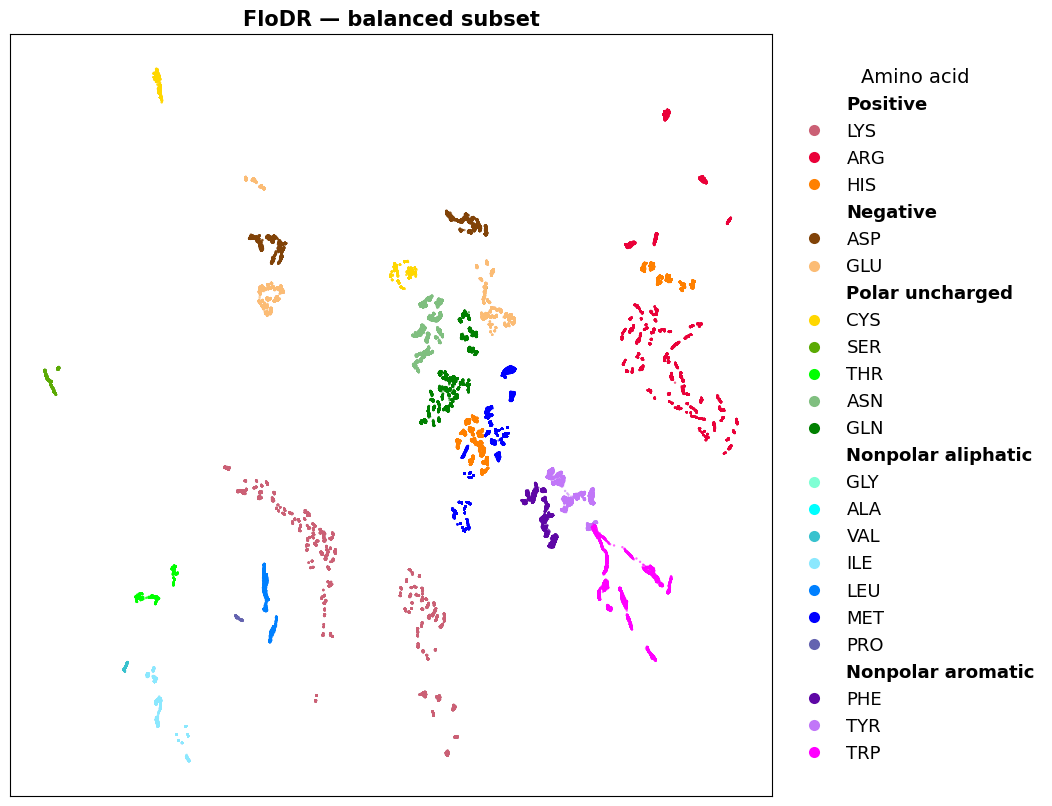

In [22]:
plot_embedding(
    flodr_balanced_display,
    FLODR_BALANCED_COORDINATE_COLUMNS,
    "FloDR — balanced subset",
)

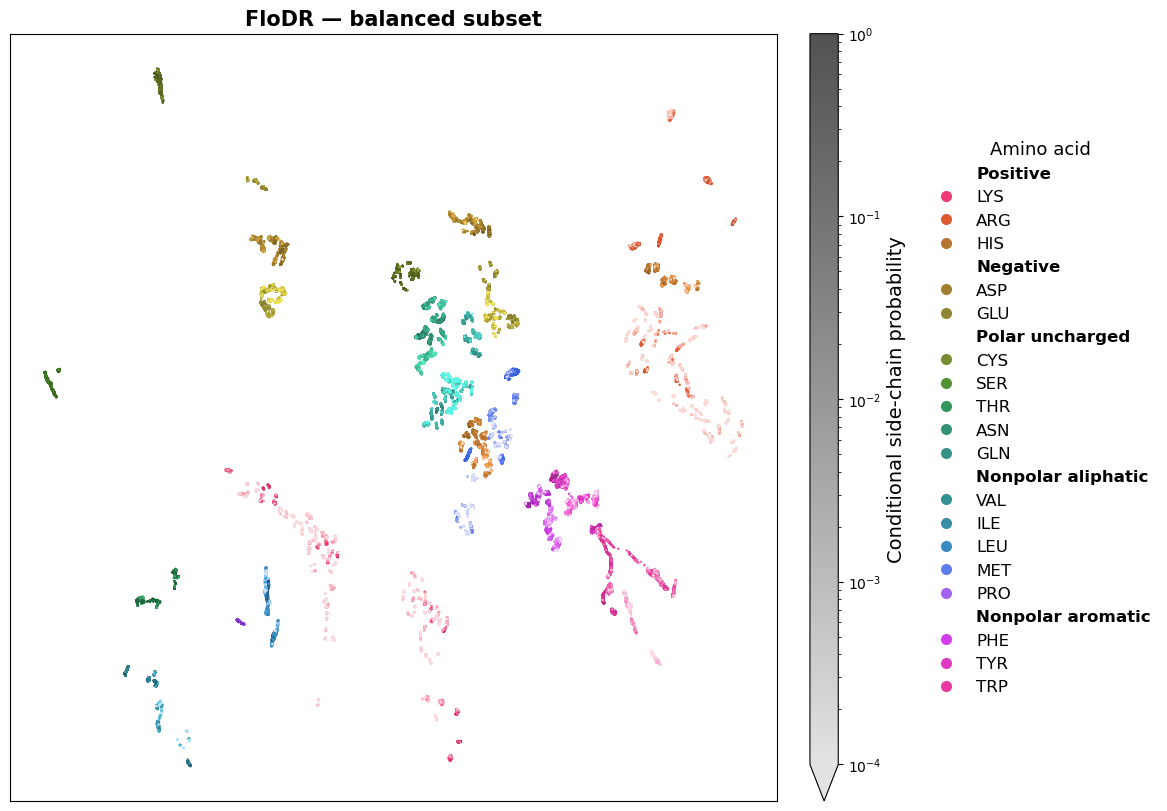

In [23]:
plot_embedding(
    flodr_balanced_display,
    FLODR_BALANCED_COORDINATE_COLUMNS,
    "FloDR — balanced subset",
    colour_by_prob=True,
)

## Full-library FloDR

Fit a separate FloDR map on all library rotamers, preserving the natural (unbalanced) amino-acid frequencies.

- Standardise all full-library descriptors together.
- Use FloDR's large-atlas batching recipe to keep GPU memory reasonable.
- Use 1600 iterations because 800 iterations provide fewer than two average passes over a million-point 15-neighbour graph.

In [17]:
# Runtime: ~3 min

FLODR_FULL_COORDINATE_COLUMNS = ["flodr_full_1", "flodr_full_2"]
FLODR_FULL_ITERATIONS = 1_600
FLODR_FULL_ADVANCED = {"gate_max": 0.5, "edge_batch": 32_768}


def load_full_library(
    names: list[str],
    path: Path = SQL_PATH,
) -> pd.DataFrame:
    """Load all finite molecular descriptors with memory-efficient numeric dtypes."""
    descriptor_select = ", ".join(
        f"CAST(json_extract(descriptors, '$.{name}') AS REAL) AS {name}"
        for name in names
    )
    query = (
        "SELECT rotamer_id, res, prob, "
        f"{descriptor_select} "
        "FROM rotamers_data WHERE descriptors IS NOT NULL ORDER BY rowid"
    )
    numeric_dtypes = {"prob": "float32", **{name: "float32" for name in names}}

    print("Loading the full RotADeL library from SQLite...")
    with connect_read_only(path) as connection:
        frame = pd.read_sql_query(query, connection, dtype=numeric_dtypes)

    expected_rows = int(library_counts.sum())
    if len(frame) != expected_rows:
        raise RuntimeError(
            f"Loaded {len(frame)} full-library rows; expected {expected_rows}."
        )
    if set(frame["res"].unique()) != set(library_counts.index):
        raise ValueError("Full-library residues do not match the database summary.")
    numeric_columns = ["prob", *names]
    if not np.isfinite(frame[numeric_columns].to_numpy(copy=False)).all():
        raise ValueError(
            "The full library contains non-finite descriptors or probabilities."
        )

    frame["rotamer_id"] = frame["rotamer_id"].astype("string")
    frame["res"] = frame["res"].astype("category")
    print(f"Full library loaded: {len(frame)} rotamers")
    return frame


flodr_full_display = load_full_library(descriptor_names)
flodr_full_scaler = StandardScaler()
flodr_full_scaled = flodr_full_scaler.fit_transform(
    flodr_full_display[descriptor_names]
).astype(np.float32, copy=False)
flodr_full_model = flodr.FloDR(
    w=2.0,
    random_state=RANDOM_SEED,
    density=False,
    n_components=2,
    advanced=FLODR_FULL_ADVANCED,
)
print(f"Full-library FloDR device: {flodr_full_model.device}")
print(
    f"Full-library FloDR configuration: {FLODR_FULL_ITERATIONS} iterations, "
    f"edge batch {FLODR_FULL_ADVANCED['edge_batch']}"
)

flodr_full_display[FLODR_FULL_COORDINATE_COLUMNS] = flodr_full_model.fit_transform(
    flodr_full_scaled,
    iters=FLODR_FULL_ITERATIONS,
)

print(f"Full-library FloDR embedding: {flodr_full_model.embedding_.shape}")
print(
    "Full-library FloDR round-trip max absolute error: "
    f"{flodr_full_model.roundtrip_:.2e}"
)

finite = np.isfinite(flodr_full_display[FLODR_FULL_COORDINATE_COLUMNS]).all(axis=1)
if omitted := int((~finite).sum()):
    print(f"Omitted {omitted} non-finite full-library FloDR points.")
    flodr_full_display = flodr_full_display.loc[finite].copy()

Loading the full RotADeL library from SQLite...
Full library loaded: 973247 rotamers
Full-library FloDR device: cuda
Full-library FloDR configuration: 1600 iterations, edge batch 32768
Full-library FloDR embedding: (973247, 2)
Full-library FloDR round-trip max absolute error: 1.85e-04


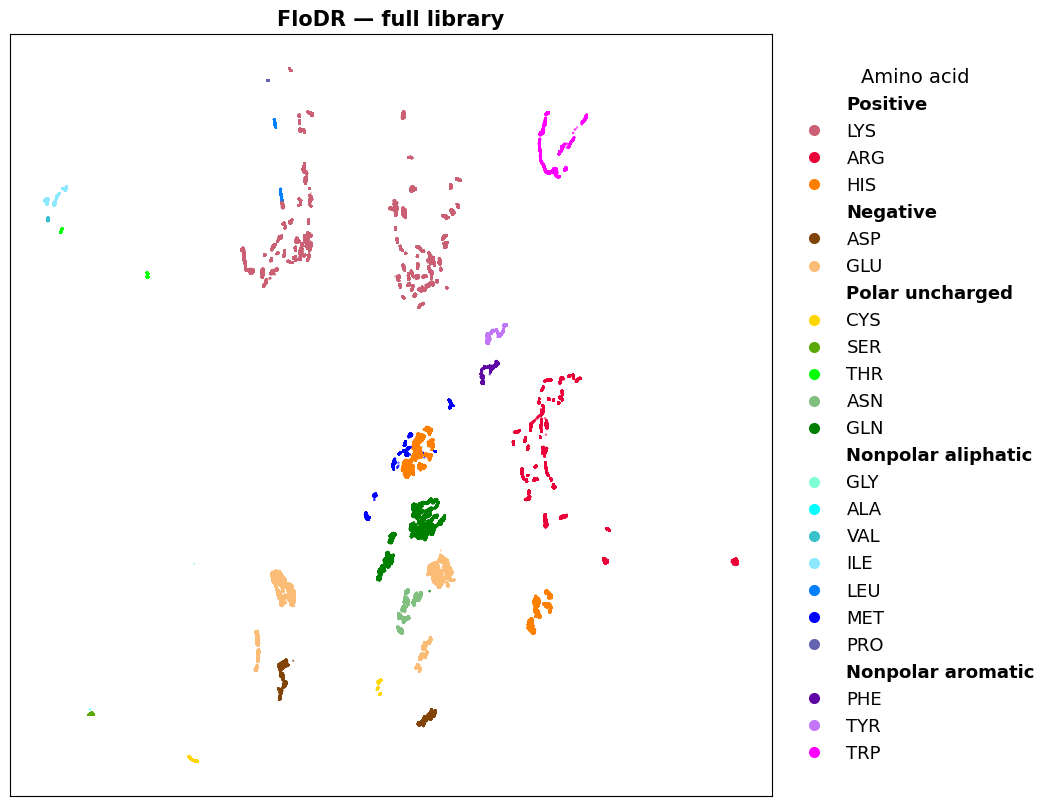

In [18]:
plot_embedding(
    flodr_full_display,
    FLODR_FULL_COORDINATE_COLUMNS,
    "FloDR — full library",
)